<a href="https://colab.research.google.com/github/khushivats0201/CODSOFT/blob/main/MOVIE_GENRE_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [3]:
from google.colab import files

print("📂 Please upload your dataset files when the picker opens...")
uploaded = files.upload()
print("\n✅ Files uploaded:", list(uploaded.keys()))

📂 Please upload your dataset files when the picker opens...


Saving test_data_solution.txt to test_data_solution.txt
Saving test_data.txt to test_data.txt
Saving train_data.txt to train_data.txt

✅ Files uploaded: ['test_data_solution.txt', 'test_data.txt', 'train_data.txt']


In [4]:
def load_train(path):
    rows = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) == 4:
                rows.append({
                    'id':          parts[0].strip(),
                    'title':       parts[1].strip(),
                    'genre':       parts[2].strip(),
                    'description': parts[3].strip()
                })
    return pd.DataFrame(rows)

def load_test(path):
    rows = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) == 3:
                rows.append({
                    'id':          parts[0].strip(),
                    'title':       parts[1].strip(),
                    'description': parts[2].strip()
                })
    return pd.DataFrame(rows)

train_df = load_train('train_data.txt')
test_df  = load_test('test_data.txt')

print(f"✅ Train samples : {len(train_df):,}")
print(f"✅ Test  samples : {len(test_df):,}")
print("\nTrain columns :", train_df.columns.tolist())
print("\nFirst 3 training rows:")
train_df.head(3)


✅ Train samples : 54,214
✅ Test  samples : 54,200

Train columns : ['id', 'title', 'genre', 'description']

First 3 training rows:


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...


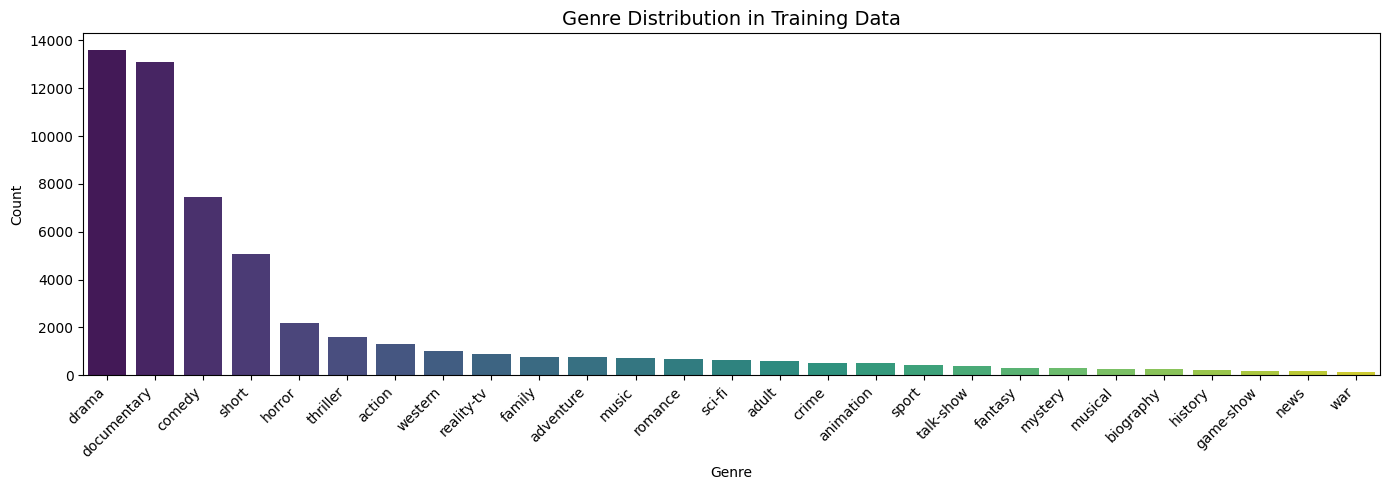


Top 10 genres:
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
Name: count, dtype: int64


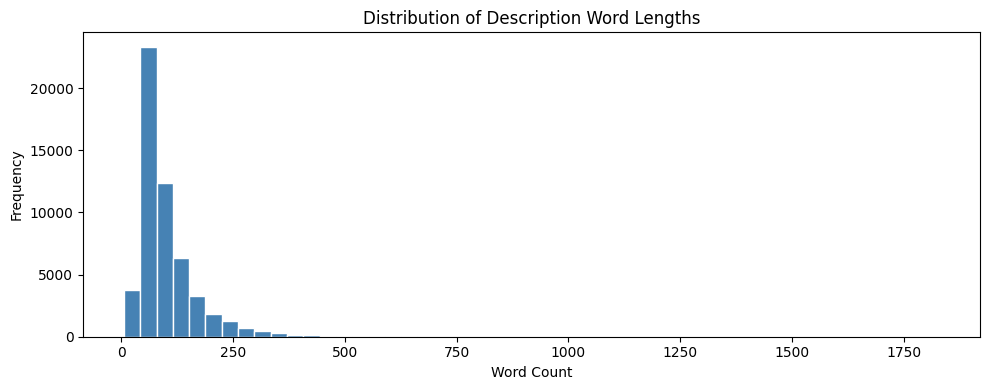


Description length stats:
count    54214.000000
mean       101.907386
std         76.579192
min          6.000000
25%         55.000000
50%         79.000000
75%        121.000000
max       1829.000000
Name: desc_len, dtype: float64


In [5]:
plt.figure(figsize=(14, 5))
genre_counts = train_df['genre'].value_counts()
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')
plt.title('Genre Distribution in Training Data', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 10 genres:")
print(genre_counts.head(10))

# 4-b  Description length distribution
train_df['desc_len'] = train_df['description'].str.split().str.len()
plt.figure(figsize=(10, 4))
plt.hist(train_df['desc_len'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Description Word Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\nDescription length stats:")
print(train_df['desc_len'].describe())

In [6]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_desc'] = train_df['description'].apply(clean_text)
test_df['clean_desc']  = test_df['description'].apply(clean_text)

# Keep only top genres (optional: keeps classes with >= 100 samples for quality)
min_samples = 100
genre_counts = train_df['genre'].value_counts()
valid_genres = genre_counts[genre_counts >= min_samples].index
train_df = train_df[train_df['genre'].isin(valid_genres)].copy()

print(f"✅ Genres kept  : {len(valid_genres)}")
print(f"✅ Train size after filter: {len(train_df):,}")
print("Genres:", sorted(valid_genres.tolist()))


✅ Genres kept  : 27
✅ Train size after filter: 54,214
Genres: ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']


In [7]:
X = train_df['clean_desc']
y = train_df['genre']

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,
    stop_words='english',
    min_df=2
)

X_tfidf = tfidf.fit_transform(X)
print(f"✅ TF-IDF matrix shape : {X_tfidf.shape}")

# Train / Validation split (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_tfidf, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"   Train : {X_train.shape[0]:,}  |  Val : {X_val.shape[0]:,}")


✅ TF-IDF matrix shape : (54214, 50000)
   Train : 43,371  |  Val : 10,843


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=5, solver='lbfgs',
                                               multi_class='multinomial'),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Linear SVM':          LinearSVC(C=1.0, max_iter=2000)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    val_preds = model.predict(X_val)
    acc = accuracy_score(y_val, val_preds)
    results[name] = acc
    print(f"  {name:25s} → Validation Accuracy: {acc:.4f} ({acc*100:.2f}%)")

best_model_name = max(results, key=results.get)
best_model      = models[best_model_name]
print(f"\n🏆 Best model : {best_model_name}  ({results[best_model_name]*100:.2f}%)")


  Logistic Regression       → Validation Accuracy: 0.5939 (59.39%)
  Naive Bayes               → Validation Accuracy: 0.5562 (55.62%)
  Linear SVM                → Validation Accuracy: 0.5827 (58.27%)

🏆 Best model : Logistic Regression  (59.39%)



  CLASSIFICATION REPORT  —  Logistic Regression
              precision    recall  f1-score   support

      action       0.55      0.37      0.44       263
       adult       0.71      0.37      0.49       118
   adventure       0.43      0.16      0.23       155
   animation       0.43      0.12      0.19       100
   biography       0.00      0.00      0.00        53
      comedy       0.53      0.61      0.57      1490
       crime       0.29      0.05      0.08       101
 documentary       0.69      0.84      0.76      2619
       drama       0.56      0.75      0.64      2723
      family       0.48      0.15      0.22       157
     fantasy       0.20      0.02      0.03        65
   game-show       0.88      0.54      0.67        39
     history       0.50      0.02      0.04        49
      horror       0.71      0.63      0.67       441
       music       0.69      0.42      0.52       146
     musical       0.43      0.05      0.10        55
     mystery       0.40      0.0

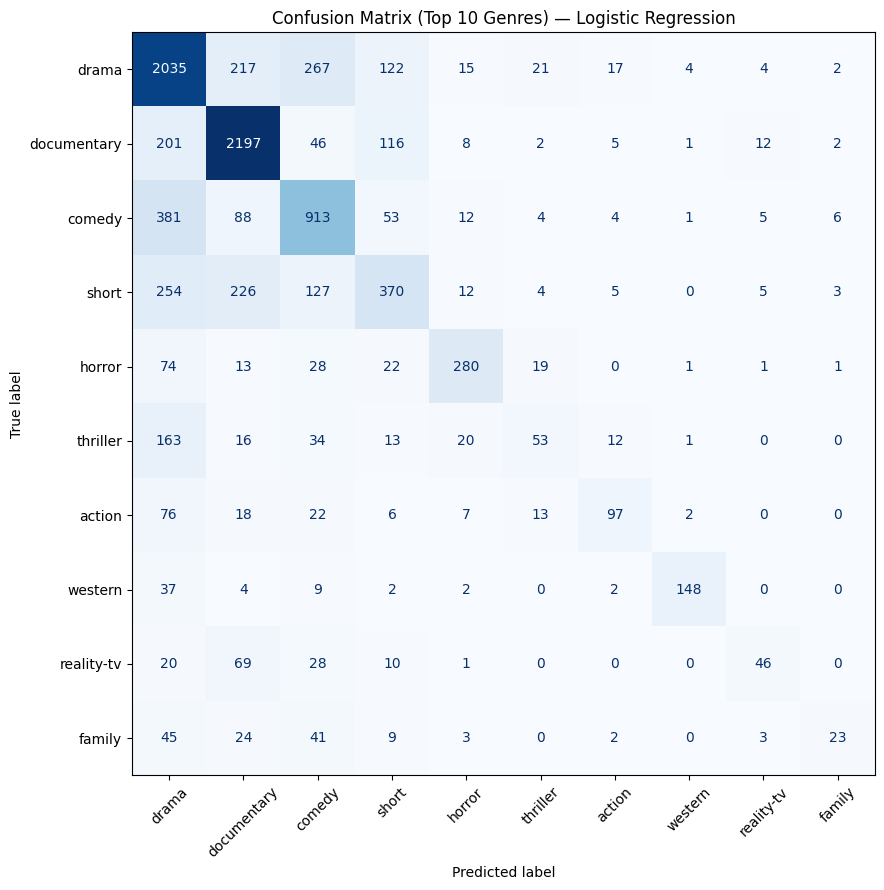

In [9]:
val_preds = best_model.predict(X_val)
y_val_labels  = le.inverse_transform(y_val)
pred_labels   = le.inverse_transform(val_preds)

print(f"\n{'='*60}")
print(f"  CLASSIFICATION REPORT  —  {best_model_name}")
print(f"{'='*60}")
print(classification_report(y_val_labels, pred_labels))

# Confusion Matrix (top-10 genres for readability)
top_genres = train_df['genre'].value_counts().head(10).index.tolist()
mask_val   = pd.Series(y_val_labels).isin(top_genres)
cm = confusion_matrix(
    pd.Series(y_val_labels)[mask_val.values],
    pd.Series(pred_labels)[mask_val.values],
    labels=top_genres
)
plt.figure(figsize=(12, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_genres)
disp.plot(cmap='Blues', xticks_rotation=45, ax=plt.gca(), colorbar=False)
plt.title(f'Confusion Matrix (Top 10 Genres) — {best_model_name}')
plt.tight_layout()
plt.show()


In [10]:
X_test_tfidf  = tfidf.transform(test_df['clean_desc'])
test_preds_enc = best_model.predict(X_test_tfidf)
test_df['predicted_genre'] = le.inverse_transform(test_preds_enc)

print("✅ Predictions done!")
print("\nSample predictions:")
print(test_df[['id', 'title', 'predicted_genre']].head(10).to_string(index=False))


✅ Predictions done!

Sample predictions:
id                                      title predicted_genre
 1                       Edgar's Lunch (1998)           drama
 2                   La guerra de papá (1977)           drama
 3                Off the Beaten Track (2010)     documentary
 4                     Meu Amigo Hindu (2015)           drama
 5                          Er nu zhai (1955)           drama
 6                         Riddle Room (2016)           drama
 7                             L'amica (1969)           drama
 8                       Ina Mina Dika (1989)          comedy
 9 Equinox Special: Britain's Tornados (2005)     documentary
10                               Press (2011)           drama


In [11]:
def load_solution(path):
    rows = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            parts = line.strip().split(' ::: ')
            if len(parts) == 4:
                rows.append({'id': parts[0].strip(), 'true_genre': parts[2].strip()})
    return pd.DataFrame(rows)

sol_df = load_solution('test_data_solution.txt')
eval_df = test_df.merge(sol_df, on='id')

# Keep only genres the model was trained on
eval_df = eval_df[eval_df['true_genre'].isin(valid_genres)]

test_acc = accuracy_score(eval_df['true_genre'], eval_df['predicted_genre'])
print(f"\n🎯 Test Set Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print("\nDetailed Test Report:")
print(classification_report(eval_df['true_genre'], eval_df['predicted_genre']))



🎯 Test Set Accuracy : 0.5973  (59.73%)

Detailed Test Report:
              precision    recall  f1-score   support

      action       0.49      0.33      0.39      1314
       adult       0.66      0.30      0.41       590
   adventure       0.63      0.22      0.32       775
   animation       0.55      0.09      0.16       498
   biography       0.00      0.00      0.00       264
      comedy       0.55      0.61      0.58      7446
       crime       0.30      0.05      0.08       505
 documentary       0.69      0.84      0.76     13096
       drama       0.56      0.76      0.64     13612
      family       0.52      0.15      0.23       783
     fantasy       0.45      0.07      0.11       322
   game-show       0.89      0.56      0.69       193
     history       0.29      0.01      0.02       243
      horror       0.67      0.61      0.63      2204
       music       0.67      0.48      0.56       731
     musical       0.40      0.04      0.08       276
     mystery      

In [12]:
output = test_df[['id', 'title', 'predicted_genre']].copy()
output.columns = ['ID', 'Title', 'Predicted_Genre']
output.to_csv('predictions.csv', index=False)

from google.colab import files
files.download('predictions.csv')
print("✅ predictions.csv downloaded!")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ predictions.csv downloaded!


In [13]:
def predict_genre(description: str) -> str:
    cleaned = clean_text(description)
    vec     = tfidf.transform([cleaned])
    pred    = best_model.predict(vec)[0]
    return le.inverse_transform([pred])[0]

# ── Try it yourself ──
my_movie = """
A group of astronauts travels to a distant planet and discovers alien life.
As they explore the surface, they must survive deadly creatures and find
a way back to Earth before their oxygen runs out.
"""
print(f"🎬 Predicted genre : {predict_genre(my_movie)}")


🎬 Predicted genre : sci-fi
